In this notebook, we load models trained with best hyperparameters and analyze their performance.

In [1]:
import json
import keras
import tensorflow as tf
import torch

from load_dataset import build_dataset, make_tf_dataset, make_torch_dataset
from model_swin_unetr import build_swin_unetr_mc

import metric_tf
import metric_torch

# Load trained models

In [2]:
unet_model_path = "output_unet3d_56.keras"
swin_model_path = "output_swin_unetr_56.pth"

unet_model = keras.models.load_model(unet_model_path, compile = False)
unet_model.compile(
    optimizer = keras.optimizers.Adam(),
    loss = metric_tf.bce_dice_loss,
    metrics=["accuracy"]
)

swin_model = build_swin_unetr_mc()
swin_model_state_dict = torch.load(swin_model_path, weights_only = False, map_location = torch.device('cpu'))
swin_model.load_state_dict(swin_model_state_dict["model_state_dict"])

<All keys matched successfully>

# Load test dataset

In [3]:
x_test, y_test = build_dataset(dataset="test")

  Loading 1/38: BraTS-PED-00002-000
  Loading 2/38: BraTS-PED-00008-000
  Loading 3/38: BraTS-PED-00009-000
  Loading 4/38: BraTS-PED-00010-000
  Loading 5/38: BraTS-PED-00028-000
  Loading 6/38: BraTS-PED-00029-000
  Loading 7/38: BraTS-PED-00032-000
  Loading 8/38: BraTS-PED-00034-000
  Loading 9/38: BraTS-PED-00041-000
  Loading 10/38: BraTS-PED-00056-000
  Loading 11/38: BraTS-PED-00061-000
  Loading 12/38: BraTS-PED-00062-000
  Loading 13/38: BraTS-PED-00063-000
  Loading 14/38: BraTS-PED-00065-000
  Loading 15/38: BraTS-PED-00068-000
  Loading 16/38: BraTS-PED-00076-000
  Loading 17/38: BraTS-PED-00077-000
  Loading 18/38: BraTS-PED-00116-000
  Loading 19/38: BraTS-PED-00117-000
  Loading 20/38: BraTS-PED-00123-000
  Loading 21/38: BraTS-PED-00138-000
  Loading 22/38: BraTS-PED-00148-000
  Loading 23/38: BraTS-PED-00152-000
  Loading 24/38: BraTS-PED-00160-000
  Loading 25/38: BraTS-PED-00161-000
  Loading 26/38: BraTS-PED-00164-000
  Loading 27/38: BraTS-PED-00173-000
  Loading 

# U-Net Inference

In [4]:
print(f"Running U-Net inference")
test_tf_dataset = make_tf_dataset(x_test, y_test, training = False)
unet_predictions = unet_model.predict(test_tf_dataset)
print(f"Predictions shape: {unet_predictions.shape}")

Running U-Net inference
76/76 ━━━━━━━━━━━━━━━━━━━━ 26s 328ms/step
Predictions shape: (304, 64, 64, 64, 1)


# U-Net Metrics

In [5]:
y_true_tf = tf.constant(y_test, dtype = tf.float32)
y_prediction_tf = tf.constant(unet_predictions, dtype = tf.float32)

unet_loss = metric_tf.bce_dice_loss(y_true_tf, y_prediction_tf).numpy()
unet_dice = metric_tf.dice_coef(y_true_tf, y_prediction_tf).numpy()
unet_hausdorffdistance = metric_torch.hausdorff_distance( # Squeeze below to remove the last dimension
    torch.from_numpy(y_test).squeeze(-1),
    torch.from_numpy(unet_predictions).squeeze(-1)
)

print(f"U-Net Loss: {unet_loss}")
print(f"U-Net Dice: {unet_dice}")
print(f"U-Net Hausdorff Distance: {unet_hausdorffdistance}")

U-Net Loss: 0.6190009117126465
U-Net Dice: 0.7887555956840515
U-Net Hausdorff Distance: 23.66427224478046


# Swin-transformer Inference

In [6]:
test_torch_dataset = make_torch_dataset(x_test, y_test, training = False)

swin_model.eval()
all_predictions = []
all_labels = []

with torch.inference_mode():
    for batch_x, batch_y in test_torch_dataset:
        prediction = swin_model(batch_x)
        prediction = torch.sigmoid(prediction)
        all_predictions.append(prediction)
        all_labels.append(batch_y)

# Join sequence of tensors
all_predictions = torch.cat(all_predictions, dim = 0)
all_labels = torch.cat(all_labels, dim = 0)

/Users/andreyestevamseabra/Documents/GitHub/CMSC324-FinalProject/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


# Swin-transformer Metrics

In [7]:
swin_loss = metric_torch.bce_dice_loss(all_labels, all_predictions).item()
swin_dice = metric_torch.dice_coef(all_labels, all_predictions).item()
swin_hausdorffdistance = metric_torch.hausdorff_distance(all_labels, all_predictions)

print(f"Swin Loss: {swin_loss}")
print(f"Swin Dice: {swin_dice}")
print(f"Swin Hausdorff Distance: {swin_hausdorffdistance}")

Swin Loss: 0.6295086145401001
Swin Dice: 0.765274703502655
Swin Hausdorff Distance: 20.591391587144177


# Plot Training Curves

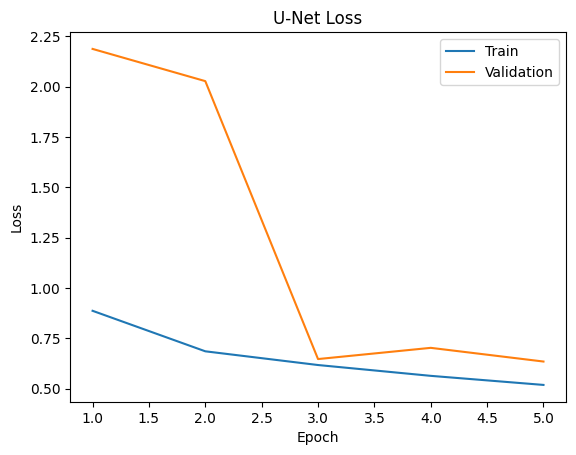

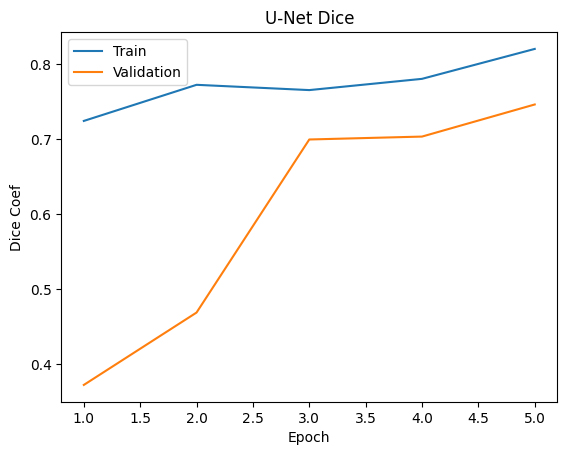

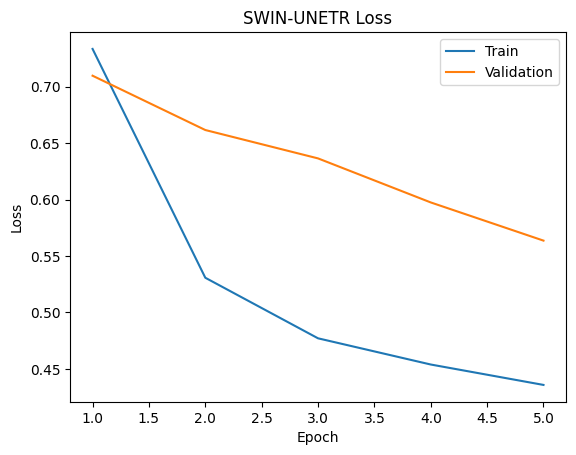

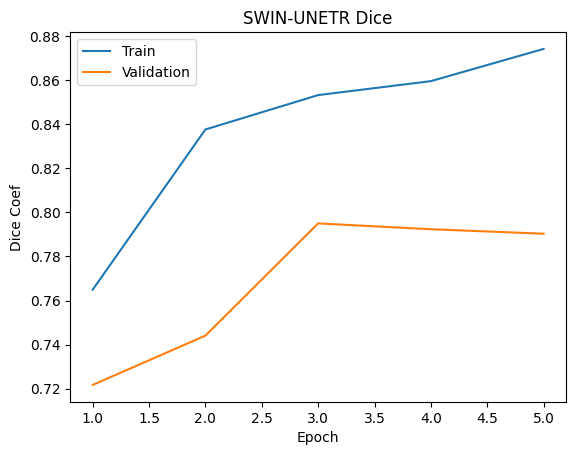

In [16]:
import json
import matplotlib.pyplot as plt

with open("unet_history.json") as unet_file:
    unet_history = json.load(unet_file)
with open("swin_history.json") as swin_file:
    swin_history = json.load(swin_file)

epochs = range(1, len(unet_history["loss"]) + 1)

# U-Net Loss plot
plt.plot(epochs, unet_history["loss"], label = "Train")
plt.plot(epochs, unet_history["val_loss"], label = "Validation")
plt.title("U-Net Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("plots/unet_loss.png", dpi = 1200, bbox_inches = 'tight')
plt.show()

# U-Net Dice plot
plt.plot(epochs, unet_history["dice_coef"], label = "Train")
plt.plot(epochs, unet_history["val_dice_coef"], label = "Validation")
plt.title("U-Net Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Coef")
plt.legend()
plt.savefig("plots/unet_dice.png", dpi = 1200, bbox_inches = 'tight')
plt.show()

# Swin Loss plot
plt.plot(epochs, swin_history["train_loss"], label = "Train")
plt.plot(epochs, swin_history["val_loss"], label = "Validation")
plt.title("SWIN-UNETR Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("plots/swin_loss.png", dpi = 1200, bbox_inches = 'tight')
plt.show()

# Swin Dice plot
plt.plot(epochs, swin_history["train_dice"], label = "Train")
plt.plot(epochs, swin_history["val_dice"], label = "Validation")
plt.title("SWIN-UNETR Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Coef")
plt.legend()
plt.savefig("plots/swin_dice.png", dpi = 1200, bbox_inches = 'tight')
plt.show()

# Plot Test Metrics Bar Chart

# Plot Sample Predictions

In [ ]:















import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Helper functions to load training history
def load_history(model_name: str):
    """
    Load the training history for a model from either a saved JSON file or a variable
    in memory (e.g. previous training run)

    Parameters:
        model_name (str): Name of the model (unet or swin)
    
    Returns:
        dict: dictionary with keys like loss, val_loss, dice_coef, val_dice_coef,
            containing lists of values (one per training epoch)
    """

    # Try to find a saved history file
    history_files = [
        Path(f"{model_name}_history.json"),
        Path(f"{model_name.lower()}_history.json"),
        Path(f"{model_name.replace(' ', '_').lower()}_history.json"),
    ]

    for history_file in history_files:
        if history_file.exists():
            with history_file.open("r", encoding="utf-8") as handle:
                return json.load(handle)
    
    # If no file found, try to find a history object in memory from a prev run in this notebook
    history_vars = {"U-Net": "unet_history", "Swin Transformer": "swin_history"}
    history_obj = globals().get(history_vars.get(model_name, ""))
    if hasattr(history_obj, "history"):
        return history_obj.history
    if isinstance(history_obj, dict):
        return history_obj
    return None

def history_series(history: dict, key: str):
    """
    Extract a specific metric from the history dictionary.

    Example: If history contains training and validation loss:
    - history_series(history, "loss") returns [0.5, 0.4, 0.3, ...]
    - history_series(history, "val_loss") returns [0.6, 0.5, 0.4, ...]

    Parameters:
        history (dict): the training history dict
        key (str): the metric to extract (e.g. loss, val_dice_coef)
    
    Returns:
        list or None: values for that metric across epochs, or None if not found
    """
    if history is None:
        return None
    values = history.get(key)

    # If validation metric not found, try the training metric instead
    if values is None and key.startswith("val_"):
        values = history.get(key[4:])
    return values

# Loading training histories for both models

# Try to load saved history for U-Net and Swin Transformer
histories = {
    "U-Net": load_history("unet"),
    "Swin Transformer": load_history("swin"),
}

# Keep only models that have history data available, i.e. remove any that returned None
histories = {}
for name, history in histories.items():
    if history is not None:
        histories[name] = history


# Plot training curves (loss and dice coefficient)
if not histories:
    print("No saved training histories found. Save each model's history as unet_history.json and swin_history.json to plot learning curves.")
else:
    # Create a figure with 2 subplots side by side
    # Subplot 1: loss curves
    # Subplot 2: dice curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Define which metrics to plot
    # Each tuple is (training_metric, validation_metric, plot_title)
    curve_specs = [
        ("loss", "val_loss", "Loss"),
        ("dice_coef", "val_dice_coef", "Dice"),
    ]

    # Define colors
    colors ={"U-Net": "tab:blue", "Swin Transformer": "tab:orange"}

    # Loop through each metric (loss and dice)
    for ax, (train_key, val_key, title) in zip(axes, curve_specs):
        plotted = False # Track if we plotted anything

        # Loop through each model
        for model_name, history in histories.items():
            # Get the training and validation values
            train_values = list(history_series(history, train_key) or [])
            val_values = list(history_series(history, val_key) or [])

            if train_values:
                # Plot the training curve (x-axis is epoch number, y axis is loss or dive value)
                ax.plot(np.arange(1, len(train_values) + 1), train_values,
                        label = f"{model_name} train", color = colors[model_name], linewidth = 2)
                plotted = True
            if val_values:
                # Plot the validation curve as a dashed line
                ax.plot(np.arange(1, len(val_values) + 1), val_values,
                        label = f"{model_name} validation", color = colors[model_name],
                        linestyle = "--", linewidth = 2)
                plotted = True
        
        # Configure the plot appearance
        ax.set_title(f"{title} curves")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.25)

        if plotted:
            ax.legend(frameon=False) # Shows which line is which
        else:
            ax.text(0.5, 0.5, f"No {title.lower()} history available",
                    ha = "center", va = "center", transform = ax.transAxes) # If no data then show a message
    
    # Adjust spacing between subplots
    plt.tight_layout()
    plt.show()

    # Plot final metrics (bar chart)
    metric_candidates = [ # Each model might have some or all of these metrics
        ("val_loss", "Validation Loss"),
        ("val_dice_coef", "Validation Dice"),
        ("val_bce", "Validation BCE"),
        ("val_hausdorff_distance", "Validation Hausdorff"),
    ]

    # Find which metrics are actually available
    available_metrics = []
    for metric_key, metric_label in metric_candidates:
        for history in histories.values():
            if history_series(history, metric_key) is not None:
                available_metrics.append((metric_key, metric_label))
                break
    
    if available_metrics:
        # Create a bar chart comparing models' final metric values
        labels = list(histories.keys())
        x = np.arange(len(labels))
        width = 0.8 / max(len(available_metrics), 1) # Calculate bar width so multiple metrics don't overlap

        fig, ax = plt.subplots(figzise = (12, 5))

        # For each metric, plot a bar for each model
        for index, (metric_key, metric_label) in enumerate(available_metrics):
            offsets = x + (index - (len (available_metrics) - 1) / 2) * width
            values = []

            # Get the final value of this metric for each model (i.e. the value from the last epoch)
            for model_name in labels:
                history = histories[model_name]
                series = list(history_series(history, metric_key) or [])
                # Take the last value from the series (final metric after training)
                values.append(series[-1] if series else np.nan)
            
            # Plot bars for this metric
            ax.bar(offsets, values, width = width, label = metric_label)
        
        # Configure bar chart appearance
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel("Final epoch value")
        ax.set_title("Final validation metric comparison")
        ax.grid(axis = "y", alpha = 0.25)
        ax.legend(frameon = False)
        plt.tight_layout()
        plt.show()
    else:
        print("No validation metrics found for a bar chart.")